In [ ]:
#!pip install tpot -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import ( train_test_split, StratifiedKFold, RandomizedSearchCV )
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix )
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tpot import TPOTClassifier

In [ ]:
df = pd.read_csv('/content/oral_microbiome.csv')
#print("Shape:", df.shape)
#df.head()

X = df.drop(columns=['sample_id', 'target'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, stratify=y, random_state=42 )

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=42 )

In [ ]:
#Modelo-XGBOOST
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

#Modelo-LIGHTGBM
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'num_leaves': [8, 16, 31]
}

#Modelo-RANDOM-SEARCH
resultados = {}

for nome, modelo, params in [
    ('XGBoost', xgb_model, xgb_params),
    ('LightGBM', lgbm_model, lgbm_params)
]:

    search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=params,
        n_iter=30,
        cv=skf,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train_scaled, y_train)

    melhor_modelo = search.best_estimator_

    y_pred = melhor_modelo.predict(X_test_scaled)
    y_prob = melhor_modelo.predict_proba(X_test_scaled)[:, 1]

    resultados[nome] = {
        'modelo': melhor_modelo,
        'best_auc_cv': search.best_score_,
        'auc_teste': roc_auc_score(y_test, y_prob),
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'params': search.best_params_
    }

#Melhor-modelo
melhor_nome = max(
    resultados,
    key=lambda x: resultados[x]['auc_teste']
)

melhor_modelo = resultados[melhor_nome]['modelo']

#Impotância-variáveis
importancias = pd.Series(
    melhor_modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


In [ ]:

#TPOT
tpot = TPOTClassifier(
    generations=3,
    population_size=10,
    cv=3,
    scorers=['f1'],
    random_state=42,
    n_jobs=1,
    max_time_mins=5
)

tpot.fit(X_train_scaled, y_train)

y_pred_tpot = tpot.predict(X_test_scaled)

try:
    y_prob_tpot = tpot.predict_proba(X_test_scaled)[:,1]

    auc_tpot = roc_auc_score(
        y_test,
        y_prob_tpot
    )
except:
    auc_tpot = np.nan

resultados["TPOT"] = {
    "accuracy": accuracy_score(y_test, y_pred_tpot),
    "f1": f1_score(y_test, y_pred_tpot),
    "auc_teste": auc_tpot
}

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36689
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46221'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:46029 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:46029
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:40590
INFO:distributed.scheduler:Receive client connection: Client-8b355ad7-6057-11f1-9eb2-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:40602
Generation: 100%|██████████| 3/3 [00:44<00:00, 14.71s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1780606499.2557259') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:46221'. Reason: nanny-close
INFO:distributed.nanny

In [ ]:
#Resultado-análise
print("="*50)
print("RESULTADOS FINAIS")
print("="*50)

for nome, res in resultados.items():

    print(f"\n{nome}")

    if nome != "TPOT":
        print(f"AUC CV     : {res['best_auc_cv']:.4f}")

    print(f"AUC TESTE  : {res['auc_teste']:.4f}")
    print(f"ACCURACY   : {res['accuracy']:.4f}")
    print(f"F1-SCORE   : {res['f1']:.4f}")

print("\nTOP 3 FILOS MAIS IMPORTANTES")

for i, (filo, valor) in enumerate(
    importancias.head(3).items(),
    start=1
):
    print(f"{i}º {filo}: {valor:.4f}")

RESULTADOS FINAIS

XGBoost
AUC CV     : 0.6772
AUC TESTE  : 0.7159
ACCURACY   : 0.6087
F1-SCORE   : 0.6667

LightGBM
AUC CV     : 0.7143
AUC TESTE  : 0.7083
ACCURACY   : 0.6087
F1-SCORE   : 0.6087

TPOT
AUC TESTE  : 0.5000
ACCURACY   : 0.5217
F1-SCORE   : 0.6857

TOP 3 FILOS MAIS IMPORTANTES
1º p__Patescibacteria: 0.3044
2º p__Spirochaetota: 0.1461
3º p__Firmicutes: 0.1351


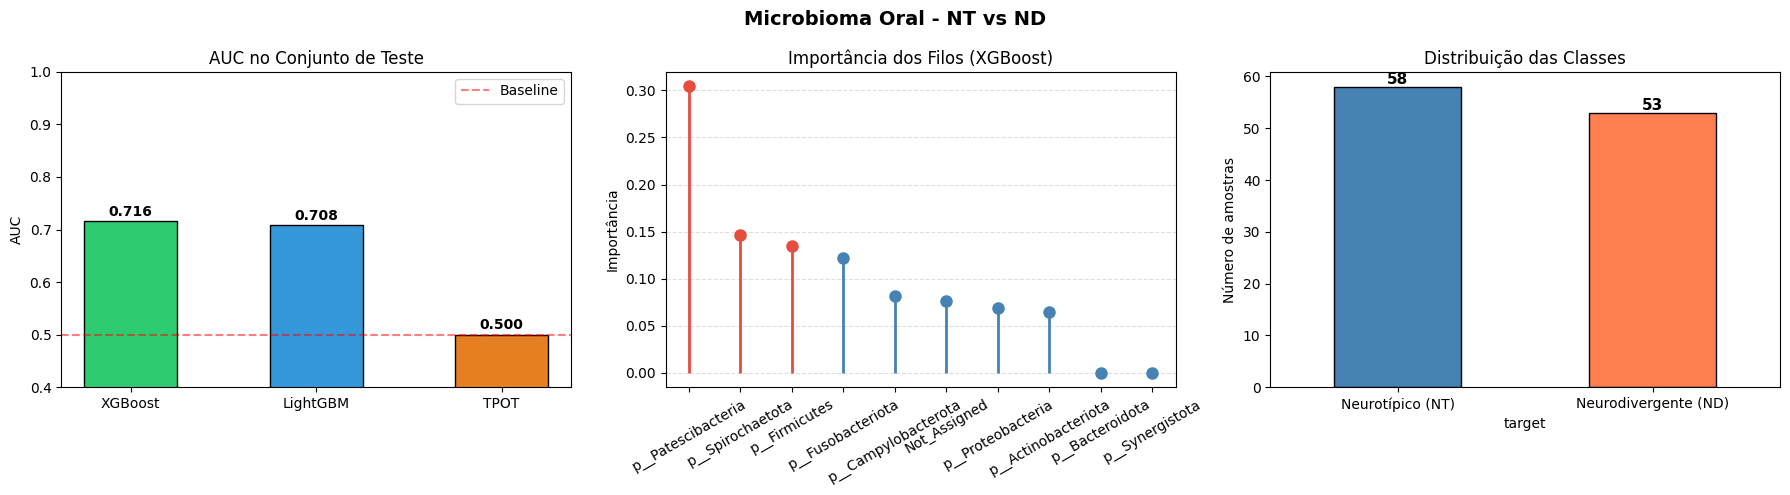

In [ ]:
#Resultados-gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Microbioma Oral - NT vs ND", fontsize=14, fontweight='bold')

# GRÁFICO 1
modelos = ['XGBoost', 'LightGBM', 'TPOT']
aucs = [resultados[m]['auc_teste'] for m in modelos]
cores = ['#2ecc71', '#3498db', '#e67e22']

axes[0].bar(modelos, aucs, color=cores, edgecolor='black', width=0.5)
axes[0].set_title("AUC no Conjunto de Teste")
axes[0].set_ylabel("AUC")
axes[0].set_ylim(0.4, 1.0)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[0].legend()
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

#GRÁFICO 2
for i, (filo, valor) in enumerate(importancias.items()):
    cor = '#e74c3c' if i < 3 else 'steelblue'
    axes[1].vlines(x=filo, ymin=0, ymax=valor, color=cor, linewidth=2)
    axes[1].plot(filo, valor, marker='o', color=cor, markersize=8)
axes[1].set_title(f'Importância dos Filos ({melhor_nome})')
axes[1].set_ylabel("Importância")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

#GRÁFICO 3
contagens = df['target'].value_counts().rename({0: 'NT', 1: 'ND'})
contagens.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black', ax=axes[2], width=0.5)
axes[2].set_title('Distribuição das Classes')
axes[2].set_ylabel('Número de amostras')
axes[2].set_xticklabels(['Neurotípico (NT)', 'Neurodivergente (ND)'], rotation=0)
for i, v in enumerate(contagens):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#Conclusões

O melhor resultado foi do XGBoost, com AUC de 0.716, o que significa que o modelo conseguiu separar os dois grupos com uma taxa de acerto razoável, bem acima do aleatório. O LightGBM ficou bem próximo com 0.708, então os dois modelos foram consistentes.
Na análise de importância, os filos Patescibacteria, Spirochaetota e Firmicutes foram os que mais contribuíram pra separar os grupos. O Patescibacteria se destacou bastante, teve importância quase duas vezes maior que os outros, o que é interessante porque é um grupo bacteriano ainda pouco estudado no contexto do neurodesenvolvimento.
No geral, os resultados mostram que existe um padrão na composição bacteriana oral que diferencia os dois grupos, mas como o dataset é pequeno, seria necessário mais dados pra confirmar essas conclusões com mais confiança.